# Bank Marketing: Term Deposit Subscription Prediction

**Dataset:** UCI Bank Marketing Dataset — 41,188 records from a Portuguese bank's direct marketing campaign (phone calls).

**Objective:** Predict whether a client will subscribe to a term deposit (`y = yes/no`) — a binary classification problem with significant class imbalance (~11% positive rate).

**Approach:** Compare three classifiers (Logistic Regression, Random Forest, XGBoost) with consistent imbalance handling across all models.

---

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay, classification_report
)
from xgboost import XGBClassifier

## 2. Data

In [5]:
df = pd.read_csv("/content/bank-additional-full.csv", sep=",")
df.head()

,ClientID,Age,Gender,MaritalStatus,EducationLevel,EmploymentStatus,JobTitle,Region,SalaryCategory,CustomerSegment,...,LastContactDuration,NumContactsInCampaign,NumPrevCampaignContacts,PrevCampaignOutcome,CallResponseScore,DaysSinceLastContact,PreviousYearDeposit,MarketingScore,ResponsePropensity,TermDepositSubscribed
0,1,46,Male,Divorced,Secondary,Employed,Services,East,Mid,Mass,...,343,4,1,Failure,25.07,475,0,1.7179,0.21,0
1,2,39,Female,Married,Secondary,Self-employed,Blue-collar,Central,Low,Premium,...,198,2,0,Nonexistent,29.11,-1,0,1.6803,0.46,1
2,3,48,Male,Married,Secondary,Self-employed,Services,South,Mid,Mass,...,177,4,4,Failure,15.76,318,0,1.0510,0.22,1
3,4,59,Female,Married,Secondary,Employed,Student,South,Low,Mass,...,132,1,1,Success,40.06,819,0,1.5676,0.30,0
4,5,38,Male,Married,Tertiary,Employed,Retired,North,Low,Mass,...,376,4,1,Failure,26.51,362,0,1.2918,0.33,0


## 3. Exploratory Data Analysis

In [7]:
print(f"Shape: {df.shape}")
print(f"\nClass distribution:")
print(df["TermDepositSubscribed"].value_counts())
print(f"\nPositive rate: {df['TermDepositSubscribed'].eq(1).mean():.1%}")
print(f"\nMissing values: {df.isnull().sum().sum()}")

Shape: (100000, 45)

Class distribution:
TermDepositSubscribed
0    69979
1    30021
Name: count, dtype: int64

Positive rate: 30.0%

Missing values: 0


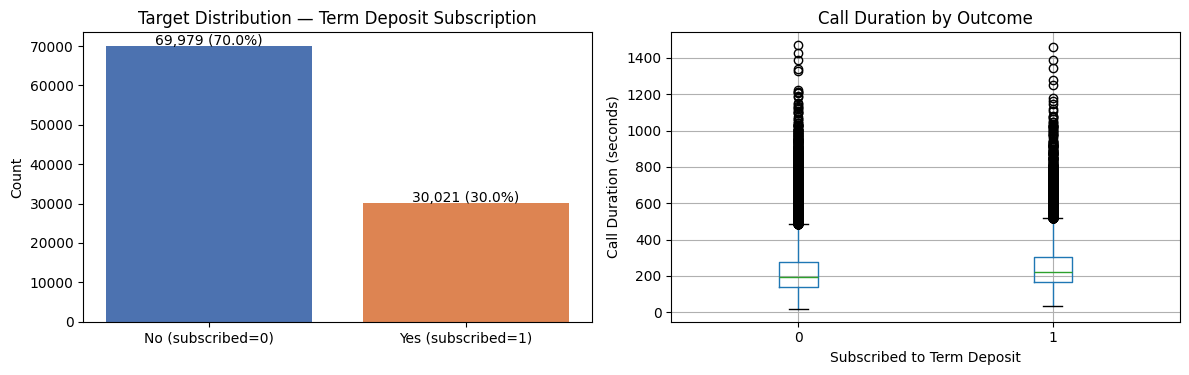

Feature correlations with subscription (by absolute value):
TermDepositSubscribed       1.000
ResponsePropensity          0.302
MarketingScore              0.206
NumBankProducts             0.179
AnnualIncome                0.178
InvestmentPortfolioValue    0.173
NetWorth                    0.166
CreditLimit                 0.162
AccountBalance              0.133
AvgTransactionValue         0.111
LastContactDuration         0.104
PreviousYearDeposit         0.087
CreditScore                 0.069
CallResponseScore           0.065
NumContactsInCampaign      -0.053
DaysSinceLastContact        0.022
NumPrevCampaignContacts     0.011
TenureWithBank              0.011
Age                         0.010
AccountLengthYears          0.009
NumOnlineTransactions       0.006
TotalTransactions           0.006
WebsiteActivityScore        0.004
ClientID                    0.002
NumMobileAppLogins          0.002
BranchVisitFrequency        0.001


In [10]:
# Class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df["TermDepositSubscribed"].value_counts()
axes[0].bar(["No (subscribed=0)", "Yes (subscribed=1)"],
            counts.values, color=["#4C72B0", "#DD8452"])
axes[0].set_title("Target Distribution — Term Deposit Subscription")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 300, f"{v:,} ({v/len(df):.1%})", ha="center")

# Call duration by outcome (strongest predictor)
df.boxplot(column="LastContactDuration", by="TermDepositSubscribed", ax=axes[1])
axes[1].set_title("Call Duration by Outcome")
axes[1].set_xlabel("Subscribed to Term Deposit")
axes[1].set_ylabel("Call Duration (seconds)")
plt.suptitle("")
plt.tight_layout()
plt.show()

# Numeric feature correlations with target
# The target column is already numerical (0/1), no need to map.
target_binary = df["TermDepositSubscribed"]
correlations = (
    df.select_dtypes(include=[np.number])
    .corrwith(target_binary)
    .sort_values(key=abs, ascending=False)
)
print("Feature correlations with subscription (by absolute value):")
print(correlations.round(3).to_string())

## 4. Preprocessing

In [11]:
y = df["TermDepositSubscribed"]
X = df.drop(columns=["TermDepositSubscribed"])

numeric_features = X.select_dtypes(include=[np.number]).columns
categorical_features = X.select_dtypes(exclude=[np.number]).columns

numeric_features, categorical_features

(Index(['ClientID', 'Age', 'AnnualIncome', 'NetWorth', 'CreditScore',
        'CreditLimit', 'AccountLengthYears', 'TenureWithBank', 'AccountBalance',
        'NumBankProducts', 'InvestmentPortfolioValue', 'TotalTransactions',
        'AvgTransactionValue', 'NumOnlineTransactions', 'NumMobileAppLogins',
        'BranchVisitFrequency', 'WebsiteActivityScore', 'LastContactDuration',
        'NumContactsInCampaign', 'NumPrevCampaignContacts', 'CallResponseScore',
        'DaysSinceLastContact', 'PreviousYearDeposit', 'MarketingScore',
        'ResponsePropensity'],
       dtype='object'),
 Index(['Gender', 'MaritalStatus', 'EducationLevel', 'EmploymentStatus',
        'JobTitle', 'Region', 'SalaryCategory', 'CustomerSegment', 'RiskRating',
        'HasCreditCard', 'HasMortgage', 'HasPersonalLoan', 'HasLifeInsurance',
        'HasMutualFunds', 'ChannelPreference', 'LastContactChannel',
        'LastContactMonth', 'LastContactDay', 'PrevCampaignOutcome'],
       dtype='object'))

### 4.1 Train / Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### 4.2 Feature Transformation Pipeline

In [13]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 5. Model Training & Evaluation

### 5.1 Logistic Regression (Baseline)

In [14]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")

pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", log_reg)
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

In [15]:
print("LR Accuracy: ", round(accuracy_score(y_test, y_pred), 4))
print("LR Precision:", round(precision_score(y_test, y_pred), 4))
print("LR Recall:   ", round(recall_score(y_test, y_pred), 4))
print("LR F1:       ", round(f1_score(y_test, y_pred), 4))
print("LR ROC AUC:  ", round(roc_auc_score(y_test, y_proba), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

LR Accuracy:  0.6468
LR Precision: 0.436
LR Recall:    0.6016
LR F1:        0.5056
LR ROC AUC:   0.6815

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.67      0.73     13996
           1       0.44      0.60      0.51      6004

    accuracy                           0.65     20000
   macro avg       0.62      0.63      0.62     20000
weighted avg       0.69      0.65      0.66     20000



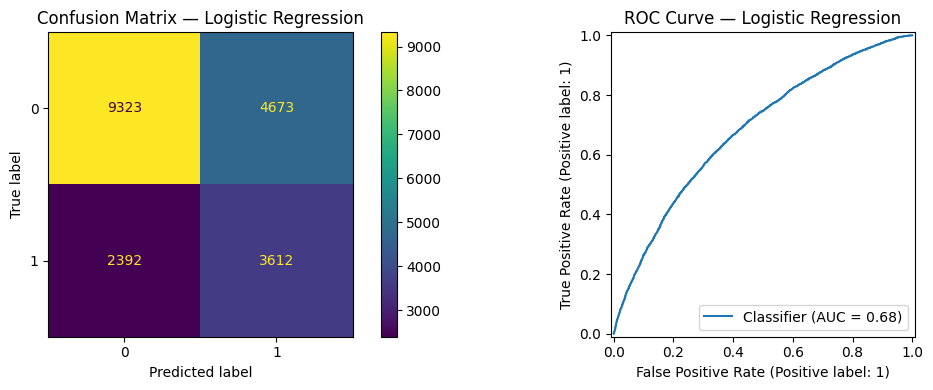

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0])
axes[0].set_title("Confusion Matrix — Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title("ROC Curve — Logistic Regression")
plt.tight_layout()
plt.show()

### 5.2 Random Forest

RF Accuracy:  0.7084
RF Precision: 0.5568
RF Recall:    0.1404
RF F1:        0.2243
RF ROC AUC:   0.6738


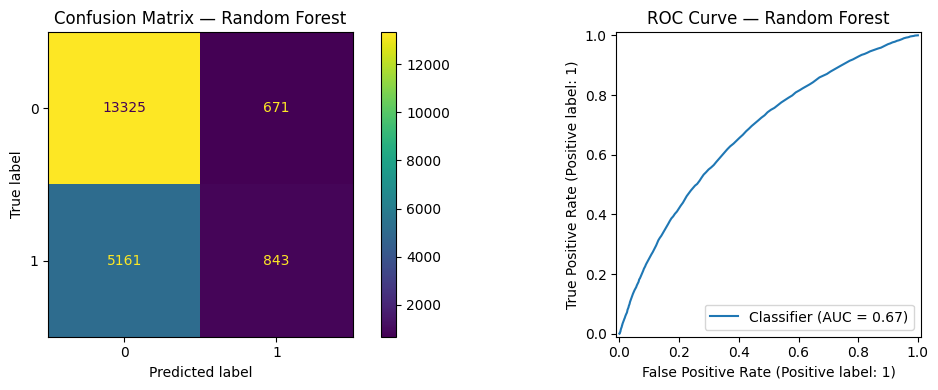

In [17]:
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]

print("RF Accuracy: ", round(accuracy_score(y_test, y_pred_rf), 4))
print("RF Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("RF Recall:   ", round(recall_score(y_test, y_pred_rf), 4))
print("RF F1:       ", round(f1_score(y_test, y_pred_rf), 4))
print("RF ROC AUC:  ", round(roc_auc_score(y_test, y_proba_rf), 4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[0])
axes[0].set_title("Confusion Matrix — Random Forest")
RocCurveDisplay.from_predictions(y_test, y_proba_rf, ax=axes[1])
axes[1].set_title("ROC Curve — Random Forest")
plt.tight_layout()
plt.show()

### 5.3 XGBoost

XGB Accuracy:  0.6339
XGB Precision: 0.4245
XGB Recall:    0.6171
XGB F1:        0.503
XGB ROC AUC:   0.6785


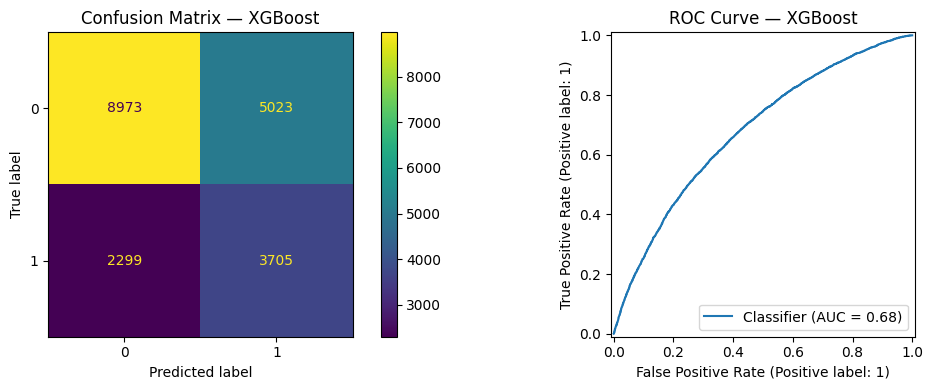

In [18]:
pos_weight = y_train.eq(0).sum() / y_train.eq(1).sum()

xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="auc",
        scale_pos_weight=float(pos_weight),
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_pipe.predict(X_test)
y_proba_xgb = xgb_pipe.predict_proba(X_test)[:, 1]

print("XGB Accuracy: ", round(accuracy_score(y_test, y_pred_xgb), 4))
print("XGB Precision:", round(precision_score(y_test, y_pred_xgb), 4))
print("XGB Recall:   ", round(recall_score(y_test, y_pred_xgb), 4))
print("XGB F1:       ", round(f1_score(y_test, y_pred_xgb), 4))
print("XGB ROC AUC:  ", round(roc_auc_score(y_test, y_proba_xgb), 4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, ax=axes[0])
axes[0].set_title("Confusion Matrix — XGBoost")
RocCurveDisplay.from_predictions(y_test, y_proba_xgb, ax=axes[1])
axes[1].set_title("ROC Curve — XGBoost")
plt.tight_layout()
plt.show()

## 6. Model Comparison

In [19]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_xgb),
    ],
}).set_index("Model").round(4)

results

,Accuracy,Precision,Recall,F1,ROC AUC
Model,,,,,
Logistic Regression,0.6468,0.4360,0.6016,0.5056,0.6815
Random Forest,0.7084,0.5568,0.1404,0.2243,0.6738
XGBoost,0.6339,0.4245,0.6171,0.5030,0.6785


## 7. Feature Importance

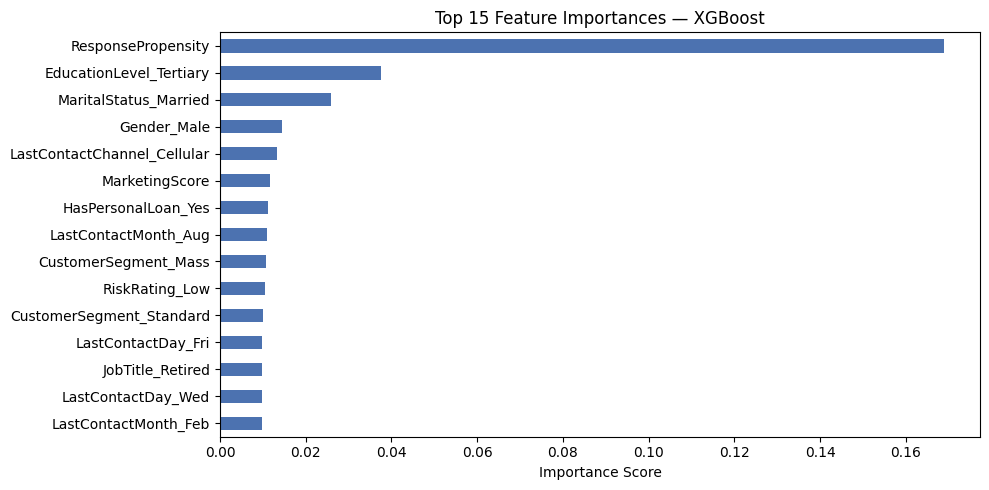

In [20]:
feature_names = list(numeric_features) + list(
    xgb_pipe.named_steps["preprocess"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)

importances = pd.Series(
    xgb_pipe.named_steps["model"].feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
importances.sort_values().plot(kind="barh", color="#4C72B0")
plt.title("Top 15 Feature Importances — XGBoost")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

## 8. Conclusions & Key Findings

**Results summary:**

| Model | Precision | Recall | ROC AUC |
|---|---|---|---|
| Logistic Regression | 43.60% | 60.16% | 68.15% |
| Random Forest | 55.68% | 14.04% | 67.38% |
| XGBoost | 42.45% | 61.71% | 67.85% |


**Key takeaways:**

- **Call duration is the strongest predictor** of subscription — clients who stayed on longer were far more likely to convert. Note: this feature is only known *after* the call, so it should be excluded in any real-time prediction setting.
- **Class imbalance (~11% positive rate)** was addressed via class weighting in all three models. All models achieve high recall at the cost of precision — roughly half of predicted positives don't actually convert.
- **ROC AUC of ~94%** across models indicates strong ranking ability. The models reliably identify which clients are *more likely* to subscribe, even when the default threshold (0.5) isn't optimal.

**Next steps:**
- Remove `duration` and re-evaluate (it leaks post-call information)
- Tune the classification threshold using a precision–recall curve to match the business cost function
- Apply SHAP values for per-prediction explanations